In [1]:
import uproot
import json
import os
import numpy as np
import sys

# plotting
import matplotlib.pyplot as plt
import mplhep as hep
hep.style.use("ATLAS")
# Enable LaTeX text rendering
plt.rcParams.update({
    "text.usetex": True,          # use LaTeX for all text
    "font.family": "serif",       # optional: use serif font
    "font.size": 12               # default font size
})

# utils
sys.path.append("./Plotting")
import Utils as ut

In [2]:
# load ALEPH result Table 54 https://www.hepdata.net/record/13011
aleph = ut.loadALEPH2004Result(hepData = "/home/badea/e+e-/aleph/UnfoldThrustResults/HEPData-ins636645-v1-Table_54.csv")

THRUST,THRUST LOW,THRUST HIGH,(1/SIG)*D(SIG)/DTHRUST,stat +,stat -,sys_1 +,sys_1 -,sys_2 +,sys_2 -


/home/badea/e+e-/aleph/unfold-ee-logtau/./Plotting/Utils.py:300: RuntimeWarning: divide by zero encountered in log
  aleph_log_bins = np.log(aleph_bins)


In [3]:
# ibu tau results
ibu_results = {}
with np.load("./Results/ibu_results.npz") as f:
    ibu_results["tau"] = {key: f[key] for key in f.keys()}
# Now both files are closed and data is stored in memory
print("IBU keys:", list(ibu_results["tau"].keys()))

IBU keys: ['nominal', 'total_stat', 'bootstrapmc', 'bootstrapdata', 'exp_syst_names', 'exp_syst', 'total_exp_syst', 'th_syst_names', 'th_syst', 'total_th_syst', 'total_uncert']


In [4]:
# load configuration
with open("training_conf.json") as f:
    training_conf = json.load(f)
print(training_conf)

# update gen to be tgen rather than tgenBefore
training_conf["gen"] = training_conf["gen"].replace("tgenBefore", "tgen") # binned unfolding and then apply the hadronic event selection correction after    

{'storage': '/home/badea/e+e-/aleph/derivations/20250625/2/', 'data': 'LEP1Data1994_recons_aftercut-MERGED_thrust_nominal_t.root', 'reco': 'alephMCRecoAfterCutPaths_1994_thrust_nominal_t.root', 'gen': 'alephMCRecoAfterCutPaths_1994_thrust_no_event_sel_tgenBefore.root', 'output_directory': './', 'niter': 5, 'layer_sizes': [100, 100, 100], 'lr': 0.0005, 'batch_size': 2048, 'epochs': 100, 'early_stop': 10, 'verbose': False, 'job_type': None, 'i_ensemble_per_omnifold': 0}


In [5]:
# nominal configuration
conf = training_conf

In [6]:
# load data files
with uproot.open(os.path.join(conf["storage"], conf["data"])) as f:
  data = np.array(f["t/Thrust"]) # data
  data_mask = np.array(f["t/passEventSelection"])
  print(data.shape, data_mask.sum())
  print(f["t"].keys())

# load mc reco
with uproot.open(os.path.join(conf["storage"], conf["reco"])) as f:
  mc_reco = np.array(f["t/Thrust"])
  mc_reco_mask = np.array(f["t/passEventSelection"])
  print(mc_reco.shape, mc_reco_mask.sum())

# load mc gen
with uproot.open(os.path.join(conf["storage"], conf["gen"])) as f:
  mc_gen = np.array(f["tgen/Thrust"])
  mc_gen_uniqueID = np.array(f["tgen/uniqueID"])
  print(mc_gen.shape)

# load mc genBefore
with uproot.open(os.path.join(conf["storage"], conf["gen"].replace("tgen", "tgenBefore"))) as f:
  mc_genBefore = np.array(f["tgenBefore/Thrust"])
  mc_genBefore_uniqueID = np.array(f["tgenBefore/uniqueID"])
  print(mc_genBefore.shape)

(1365440,) 1326312
['uniqueID', 'Thrust', 'TotalTrkEnergy', 'NTrk', 'Neu', 'STheta', 'Sphericity', 'MissP', 'EVis', 'TTheta', 'passEventSelection', 'NSelectedParticles', 'px', 'py', 'pz', 'pwflag', 'conversionElectronTheta', 'conversionElectronPhi', 'conversionElectronPt']
(771597,) 751861
(771597,)
(973769,)


In [7]:
# convert from thrust to tau = 1-T
data = 1-data
mc_reco = 1-mc_reco
mc_gen = 1-mc_gen
mc_genBefore = 1-mc_genBefore

In [8]:
# histogram
bins = np.linspace(0, 0.42, 43) # tau bins
bin_widths = bins[1:] - bins[:-1]
bin_centers = (bins[:-1] + bins[1:]) / 2
density = False

# histogram
data_hist, data_hist_stat_uncert, _ = ut.calc_hist(data[data_mask], bins=bins, density=density)
reco_hist, reco_hist_stat_uncert, _ = ut.calc_hist(mc_reco[mc_reco_mask], bins=bins, density=density)
gen_hist,  gen_hist_stat_uncert,  _ = ut.calc_hist(mc_gen[mc_reco_mask], bins=bins, density=density)
genb_hist, genb_hist_stat_uncert, _ = ut.calc_hist(mc_genBefore, bins=bins, density=density)

In [9]:
# normalizations
data_hist_norm = data_hist.sum() * bin_widths
reco_hist_norm = reco_hist.sum() * bin_widths
gen_hist_norm = gen_hist.sum() * bin_widths
genb_hist_norm = genb_hist.sum() * bin_widths

In [10]:
# compute aleph (2004) ratio to genb
aleph_to_genb, aleph_to_genb_uncert = ut.ratio_with_uncertainty(
    aleph["aleph_thrust"], 
    genb_hist / genb_hist_norm, 
    aleph["aleph_thrust_errs"], 
    genb_hist_stat_uncert / genb_hist_norm
)

# compute aleph (2004) ratio to genb
ibu_to_genb, ibu_to_genb_uncert = ut.ratio_with_uncertainty(
    ibu_results["tau"]["nominal"], 
    genb_hist / genb_hist_norm, 
    ibu_results["tau"]["total_uncert"], 
    genb_hist_stat_uncert / genb_hist_norm
)

# compute data ratio to genb
data_to_genb, data_to_genb_uncert = ut.ratio_with_uncertainty(
    data_hist / data_hist_norm, 
    genb_hist / genb_hist_norm, 
    data_hist_stat_uncert / data_hist_norm, 
    genb_hist_stat_uncert / genb_hist_norm
)

# compute reco ratio to genb
reco_to_genb, reco_to_genb_uncert = ut.ratio_with_uncertainty(
    reco_hist / reco_hist_norm, 
    genb_hist / genb_hist_norm, 
    reco_hist_stat_uncert / reco_hist_norm, 
    genb_hist_stat_uncert / genb_hist_norm
)

# compute gen ratio to genb
gen_to_genb, gen_to_genb_uncert = ut.ratio_with_uncertainty(
    gen_hist / gen_hist_norm, 
    genb_hist / genb_hist_norm, 
    gen_hist_stat_uncert / gen_hist_norm, 
    genb_hist_stat_uncert / genb_hist_norm
)

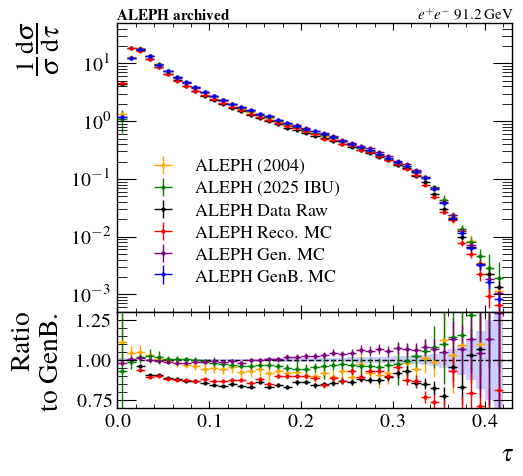

In [11]:
# closure check
fig, axs = plt.subplots(
    2, 1,
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]},  # top panel taller, bottom three equal
    figsize=[5,5]
)
plt.subplots_adjust(hspace=0)

# aleph
axs[0].errorbar(
    aleph["aleph_midbins"], 
    aleph["aleph_thrust"],
    xerr=aleph["aleph_binwidths"]/2,
    yerr=aleph["aleph_thrust_errs"], 
    marker=".", 
    linestyle="None", 
    color="orange", 
    alpha=1, 
    label="ALEPH (2004)", 
    markersize=4, 
    linewidth=1
)

# ibu
axs[0].errorbar(
    aleph["aleph_midbins"], 
    ibu_results["tau"]["nominal"],
    xerr=aleph["aleph_binwidths"]/2,
    yerr=ibu_results["tau"]["total_uncert"], 
    marker=".", 
    linestyle="None", 
    color="green", 
    alpha=1, 
    label="ALEPH (2025 IBU)", 
    markersize=4, 
    linewidth=1
)

# data
axs[0].errorbar(
    bin_centers, 
    data_hist / data_hist_norm, 
    xerr=bin_widths/2, 
    yerr=data_hist_stat_uncert / data_hist_norm, 
    marker=".", 
    linestyle="None", 
    color="k", 
    alpha=1, 
    ecolor='k', 
    label="ALEPH Data Raw", 
    markersize=4, 
    linewidth=1
)

# reco mc
axs[0].errorbar(
    bin_centers, 
    reco_hist / reco_hist_norm, 
    xerr=bin_widths/2, 
    yerr=reco_hist_stat_uncert / reco_hist_norm, 
    marker=".", 
    linestyle="None", 
    color="r", 
    alpha=1, 
    ecolor='r', 
    label="ALEPH Reco. MC", 
    markersize=4, 
    linewidth=1
)

# mc gen
axs[0].errorbar(
    bin_centers, 
    gen_hist / gen_hist_norm, 
    xerr=bin_widths/2, 
    yerr=gen_hist_stat_uncert / gen_hist_norm, 
    marker=".", 
    linestyle="None", 
    color="purple", 
    alpha=1, 
    # ecolor='p', 
    label="ALEPH Gen. MC", 
    markersize=4, 
    linewidth=1
)

# mc gen
axs[0].errorbar(
    bin_centers, 
    genb_hist / genb_hist_norm, 
    xerr=bin_widths/2, 
    yerr=genb_hist_stat_uncert / genb_hist_norm, 
    marker=".", 
    linestyle="None", 
    color="b", 
    alpha=1, 
    ecolor='b', 
    label="ALEPH GenB. MC", 
    markersize=4, 
    linewidth=1
)

# header
axs[0].text(0, 1.0, r"$\textbf{ALEPH\ archived}$", transform=axs[0].transAxes, ha='left', va='bottom', fontsize=11)
axs[0].text(0.76, 1.0, r"$e^{+}e^{-}$ 91.2 GeV", transform=axs[0].transAxes, ha='left', va='bottom', fontsize=11)

# labels
axs[0].set_ylabel(r"$\frac{{1}}{{\sigma}} \frac{{\mathrm{d}\sigma}}{{\mathrm{d}\tau}}$", fontsize=25)
axs[0].set_yscale("log")
axs[0].set_ylim(5*10**-4, 5*10**1)

# legend
axs[0].legend(ncol=1, fontsize=13, title="", title_fontsize=15)

# ratios
axs[1].axhline(y=1, color='black', linestyle='--', alpha=1, lw=1)
axs[1].set_ylim(0.7, 1.3)
axs[1].set_xlim(0, 0.43)
axs[1].set_xlabel(r"$\tau$")
axs[1].set_ylabel("Ratio\nto GenB.", fontsize=20)

# plot unifold uncertainty band
ut.plotBand(
    axs[1], 
    bin_centers, 
    np.ones(bin_centers.shape), 
    genb_hist_stat_uncert/genb_hist, 
    bin_widths, 
    "blue", 
    alpha=0.2
)

# aleph 
axs[1].errorbar(
    aleph["aleph_midbins"], 
    aleph_to_genb,
    xerr=aleph["aleph_binwidths"]/2,
    yerr=aleph_to_genb_uncert, 
    marker=".", 
    linestyle="None", 
    color="orange", 
    alpha=1, 
    label="ALEPH (2004)", 
    markersize=4, 
    linewidth=1
)

# ibu
axs[1].errorbar(
    aleph["aleph_midbins"], 
    ibu_to_genb,
    xerr=aleph["aleph_binwidths"]/2,
    yerr=ibu_to_genb_uncert, 
    marker=".", 
    linestyle="None", 
    color="green", 
    alpha=1, 
    label="ALEPH (2025 IBU)", 
    markersize=4, 
    linewidth=1
)

# data
axs[1].errorbar(
    bin_centers, 
    data_to_genb, 
    xerr=bin_widths/2, 
    yerr= data_to_genb_uncert, 
    marker=".", 
    linestyle="None", 
    color="k", 
    alpha=1, 
    ecolor='k', 
    label="ALEPH Data Raw", 
    markersize=4, 
    linewidth=1
)

# reco mc
axs[1].errorbar(
    bin_centers, 
    reco_to_genb, 
    xerr=bin_widths/2, 
    yerr=reco_to_genb_uncert, 
    marker=".", 
    linestyle="None", 
    color="r", 
    alpha=1, 
    ecolor='r', 
    label="ALEPH Reco. MC", 
    markersize=4, 
    linewidth=1
)

# mc gen
axs[1].errorbar(
    bin_centers, 
    gen_to_genb,
    xerr=bin_widths/2, 
    yerr=gen_to_genb_uncert,
    marker=".", 
    linestyle="None", 
    color="purple", 
    alpha=1, 
    # ecolor='p', 
    label="ALEPH Gen. MC", 
    markersize=4, 
    linewidth=1
)

plt.show()

In [12]:
# compute bin-by-bin detector and hadronic event selection
det_corr = gen_hist/(reco_hist + 10**-50)
had_corr = genb_hist/(gen_hist + 10**-50)

In [13]:
# corrected data
data_hist_det_corr = data_hist * det_corr
data_hist_det_corr_norm = data_hist_det_corr.sum() * bin_widths
data_hist_det_corr_stat_uncert = data_hist_stat_uncert * det_corr

# compute data ratio to genb
data_det_corr_to_genb, data_det_corr_to_genb_uncert = ut.ratio_with_uncertainty(
    data_hist_det_corr / data_hist_det_corr_norm, 
    genb_hist / genb_hist_norm, 
    data_hist_det_corr_stat_uncert / data_hist_det_corr_norm, 
    genb_hist_stat_uncert / genb_hist_norm
)

# corrected data
data_hist_det_had_corr = data_hist * det_corr * had_corr
data_hist_det_had_corr_norm = data_hist_det_had_corr.sum() * bin_widths
data_hist_det_had_corr_stat_uncert = data_hist_stat_uncert * det_corr * had_corr

# compute data ratio to genb
data_det_had_corr_to_genb, data_det_had_corr_to_genb_uncert = ut.ratio_with_uncertainty(
    data_hist_det_had_corr / data_hist_det_had_corr_norm, 
    genb_hist / genb_hist_norm, 
    data_hist_det_had_corr_stat_uncert / data_hist_det_had_corr_norm, 
    genb_hist_stat_uncert / genb_hist_norm
)

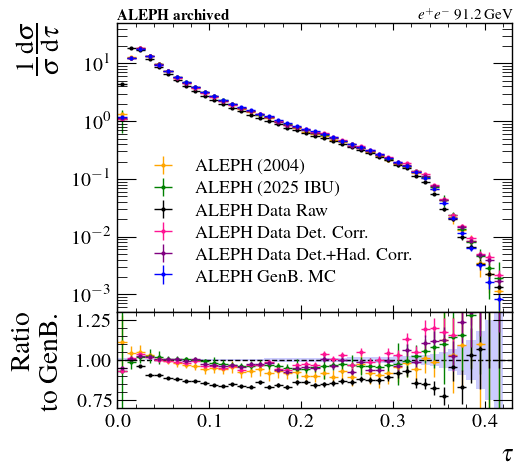

In [14]:
# closure check
fig, axs = plt.subplots(
    2, 1,
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]},  # top panel taller, bottom three equal
    figsize=[5,5]
)
plt.subplots_adjust(hspace=0)

# aleph
axs[0].errorbar(
    aleph["aleph_midbins"], 
    aleph["aleph_thrust"],
    xerr=aleph["aleph_binwidths"]/2,
    yerr=aleph["aleph_thrust_errs"], 
    marker=".", 
    linestyle="None", 
    color="orange", 
    alpha=1, 
    label="ALEPH (2004)", 
    markersize=4, 
    linewidth=1
)

# ibu
axs[0].errorbar(
    aleph["aleph_midbins"], 
    ibu_results["tau"]["nominal"],
    xerr=aleph["aleph_binwidths"]/2,
    yerr=ibu_results["tau"]["total_uncert"], 
    marker=".", 
    linestyle="None", 
    color="green", 
    alpha=1, 
    label="ALEPH (2025 IBU)", 
    markersize=4, 
    linewidth=1
)

# data
axs[0].errorbar(
    bin_centers, 
    data_hist / data_hist_norm, 
    xerr=bin_widths/2, 
    yerr=data_hist_stat_uncert / data_hist_norm, 
    marker=".", 
    linestyle="None", 
    color="k", 
    alpha=1, 
    ecolor='k', 
    label="ALEPH Data Raw", 
    markersize=4, 
    linewidth=1
)

# data
axs[0].errorbar(
    bin_centers, 
    data_hist_det_corr / data_hist_det_corr_norm, 
    xerr=bin_widths/2, 
    yerr=data_hist_det_corr_stat_uncert / data_hist_det_corr_norm, 
    marker=".", 
    linestyle="None", 
    color="deeppink", 
    alpha=1, 
    # ecolor='k', 
    label="ALEPH Data Det. Corr.", 
    markersize=4, 
    linewidth=1
)

# data
axs[0].errorbar(
    bin_centers, 
    data_hist_det_had_corr / data_hist_det_had_corr_norm, 
    xerr=bin_widths/2, 
    yerr=data_hist_det_had_corr_stat_uncert / data_hist_det_had_corr_norm, 
    marker=".", 
    linestyle="None", 
    color="purple", 
    alpha=1, 
    # ecolor='k', 
    label="ALEPH Data Det.+Had. Corr.", 
    markersize=4, 
    linewidth=1
)

# mc gen
axs[0].errorbar(
    bin_centers, 
    genb_hist / genb_hist_norm, 
    xerr=bin_widths/2, 
    yerr=genb_hist_stat_uncert / genb_hist_norm, 
    marker=".", 
    linestyle="None", 
    color="b", 
    alpha=1, 
    ecolor='b', 
    label="ALEPH GenB. MC", 
    markersize=4, 
    linewidth=1
)

# header
axs[0].text(0, 1.0, r"$\textbf{ALEPH\ archived}$", transform=axs[0].transAxes, ha='left', va='bottom', fontsize=11)
axs[0].text(0.76, 1.0, r"$e^{+}e^{-}$ 91.2 GeV", transform=axs[0].transAxes, ha='left', va='bottom', fontsize=11)

# labels
axs[0].set_ylabel(r"$\frac{{1}}{{\sigma}} \frac{{\mathrm{d}\sigma}}{{\mathrm{d}\tau}}$", fontsize=25)
axs[0].set_yscale("log")
axs[0].set_ylim(5*10**-4, 5*10**1)

# legend
axs[0].legend(ncol=1, fontsize=13, title="", title_fontsize=15)

# ratios
axs[1].axhline(y=1, color='black', linestyle='--', alpha=1, lw=1)
axs[1].set_ylim(0.7, 1.3)
axs[1].set_xlim(0, 0.43)
axs[1].set_xlabel(r"$\tau$")
axs[1].set_ylabel("Ratio\nto GenB.", fontsize=20)

# plot unifold uncertainty band
ut.plotBand(
    axs[1], 
    bin_centers, 
    np.ones(bin_centers.shape), 
    genb_hist_stat_uncert/genb_hist, 
    bin_widths, 
    "blue", 
    alpha=0.2
)

# aleph 
axs[1].errorbar(
    aleph["aleph_midbins"], 
    aleph_to_genb,
    xerr=aleph["aleph_binwidths"]/2,
    yerr=aleph_to_genb_uncert, 
    marker=".", 
    linestyle="None", 
    color="orange", 
    alpha=1, 
    label="ALEPH (2004)", 
    markersize=4, 
    linewidth=1
)

# ibu
axs[1].errorbar(
    aleph["aleph_midbins"], 
    ibu_to_genb,
    xerr=aleph["aleph_binwidths"]/2,
    yerr=ibu_to_genb_uncert, 
    marker=".", 
    linestyle="None", 
    color="green", 
    alpha=1, 
    label="ALEPH (2025 IBU)", 
    markersize=4, 
    linewidth=1
)

# data
axs[1].errorbar(
    bin_centers, 
    data_to_genb, 
    xerr=bin_widths/2, 
    yerr= data_to_genb_uncert, 
    marker=".", 
    linestyle="None", 
    color="k", 
    alpha=1, 
    ecolor='k', 
    label="ALEPH Data Raw", 
    markersize=4, 
    linewidth=1
)

# data
axs[1].errorbar(
    bin_centers, 
    data_det_corr_to_genb, 
    xerr=bin_widths/2, 
    yerr=data_det_corr_to_genb_uncert, 
    marker=".", 
    linestyle="None", 
    color="deeppink", 
    alpha=1, 
    # ecolor='k', 
    label="ALEPH Data Det. Corr.", 
    markersize=4, 
    linewidth=1
)

# data
axs[1].errorbar(
    bin_centers, 
    data_det_had_corr_to_genb, 
    xerr=bin_widths/2, 
    yerr=data_det_had_corr_to_genb_uncert,
    marker=".", 
    linestyle="None", 
    color="purple", 
    alpha=1, 
    # ecolor='k', 
    label="ALEPH Data Det.+Had. Corr.", 
    markersize=4, 
    linewidth=1
)

plt.show()

In [15]:
# compute data ratio to genb
data_to_aleph, data_to_aleph_uncert = ut.ratio_with_uncertainty(
    data_hist / data_hist_norm, 
    aleph["aleph_thrust"], 
    data_hist_stat_uncert / data_hist_norm, 
    aleph["aleph_thrust_errs"]
)

# compute ibu to aleph (2004)
ibu_to_aleph, ibu_to_aleph_uncert = ut.ratio_with_uncertainty(
    ibu_results["tau"]["nominal"], 
    aleph["aleph_thrust"], 
    ibu_results["tau"]["total_uncert"], 
    aleph["aleph_thrust_errs"]
)

# compute aleph (2004) ratio to genb
genb_to_aleph, genb_to_aleph_uncert = ut.ratio_with_uncertainty(
    genb_hist / genb_hist_norm,
    aleph["aleph_thrust"], 
    genb_hist_stat_uncert / genb_hist_norm,
    aleph["aleph_thrust_errs"]
)

# compute data with det. corr. to aleph (2004)
data_det_corr_to_aleph, data_det_corr_to_aleph_uncert = ut.ratio_with_uncertainty(
    data_hist_det_corr / data_hist_det_corr_norm, 
    aleph["aleph_thrust"], 
    data_hist_det_corr_stat_uncert / data_hist_det_corr_norm, 
    aleph["aleph_thrust_errs"]
)

# compute data with det. and had. corr to aleph (2004)
data_det_had_corr_to_aleph, data_det_had_corr_to_aleph_uncert = ut.ratio_with_uncertainty(
    data_hist_det_had_corr / data_hist_det_had_corr_norm, 
    aleph["aleph_thrust"], 
    data_hist_det_had_corr_stat_uncert / data_hist_det_had_corr_norm, 
    aleph["aleph_thrust_errs"]
)

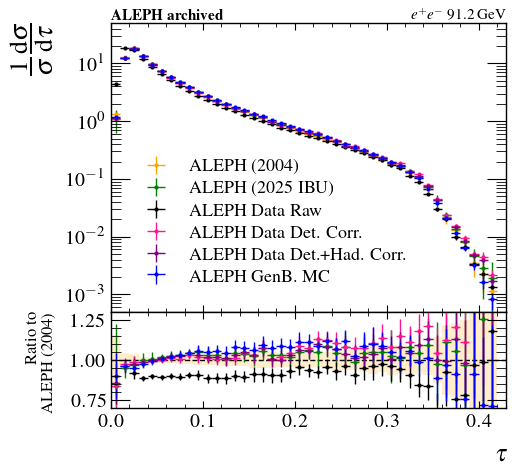

In [16]:
# closure check
fig, axs = plt.subplots(
    2, 1,
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]},  # top panel taller, bottom three equal
    figsize=[5,5]
)
plt.subplots_adjust(hspace=0)

# aleph
axs[0].errorbar(
    aleph["aleph_midbins"], 
    aleph["aleph_thrust"],
    xerr=aleph["aleph_binwidths"]/2,
    yerr=aleph["aleph_thrust_errs"], 
    marker=".", 
    linestyle="None", 
    color="orange", 
    alpha=1, 
    label="ALEPH (2004)", 
    markersize=4, 
    linewidth=1
)

# ibu
axs[0].errorbar(
    aleph["aleph_midbins"], 
    ibu_results["tau"]["nominal"],
    xerr=aleph["aleph_binwidths"]/2,
    yerr=ibu_results["tau"]["total_uncert"], 
    marker=".", 
    linestyle="None", 
    color="green", 
    alpha=1, 
    label="ALEPH (2025 IBU)", 
    markersize=4, 
    linewidth=1
)

# data
axs[0].errorbar(
    bin_centers, 
    data_hist / data_hist_norm, 
    xerr=bin_widths/2, 
    yerr=data_hist_stat_uncert / data_hist_norm, 
    marker=".", 
    linestyle="None", 
    color="k", 
    alpha=1, 
    ecolor='k', 
    label="ALEPH Data Raw", 
    markersize=4, 
    linewidth=1
)

# data
axs[0].errorbar(
    bin_centers, 
    data_hist_det_corr / data_hist_det_corr_norm, 
    xerr=bin_widths/2, 
    yerr=data_hist_det_corr_stat_uncert / data_hist_det_corr_norm, 
    marker=".", 
    linestyle="None", 
    color="deeppink", 
    alpha=1, 
    # ecolor='k', 
    label="ALEPH Data Det. Corr.", 
    markersize=4, 
    linewidth=1
)

# data
axs[0].errorbar(
    bin_centers, 
    data_hist_det_had_corr / data_hist_det_had_corr_norm, 
    xerr=bin_widths/2, 
    yerr=data_hist_det_had_corr_stat_uncert / data_hist_det_had_corr_norm, 
    marker=".", 
    linestyle="None", 
    color="purple", 
    alpha=1, 
    # ecolor='k', 
    label="ALEPH Data Det.+Had. Corr.", 
    markersize=4, 
    linewidth=1
)

# mc gen
axs[0].errorbar(
    bin_centers, 
    genb_hist / genb_hist_norm, 
    xerr=bin_widths/2, 
    yerr=genb_hist_stat_uncert / genb_hist_norm, 
    marker=".", 
    linestyle="None", 
    color="b", 
    alpha=1, 
    ecolor='b', 
    label="ALEPH GenB. MC", 
    markersize=4, 
    linewidth=1
)

# header
axs[0].text(0, 1.0, r"$\textbf{ALEPH\ archived}$", transform=axs[0].transAxes, ha='left', va='bottom', fontsize=11)
axs[0].text(0.76, 1.0, r"$e^{+}e^{-}$ 91.2 GeV", transform=axs[0].transAxes, ha='left', va='bottom', fontsize=11)

# labels
axs[0].set_ylabel(r"$\frac{{1}}{{\sigma}} \frac{{\mathrm{d}\sigma}}{{\mathrm{d}\tau}}$", fontsize=25)
axs[0].set_yscale("log")
axs[0].set_ylim(5*10**-4, 5*10**1)

# legend
axs[0].legend(ncol=1, fontsize=13, title="", title_fontsize=15)

# ratios
axs[1].axhline(y=1, color='black', linestyle='--', alpha=1, lw=1)
axs[1].set_ylim(0.7, 1.3)
axs[1].set_xlim(0, 0.43)
axs[1].set_xlabel(r"$\tau$")
axs[1].set_ylabel("Ratio to\n ALEPH (2004)", fontsize=12)
# axs[1].set_ylabel(r"$\frac{{\mathrm{Data}}}{{\mathrm{ALEPH(2004)}}}$", fontsize=20)

# plot unifold uncertainty band
ut.plotBand(
    axs[1], 
    bin_centers, 
    np.ones(bin_centers.shape), 
    aleph["aleph_thrust_errs"]/aleph["aleph_thrust"], 
    bin_widths, 
    "orange", 
    alpha=0.2
)

# ibu
axs[1].errorbar(
    aleph["aleph_midbins"], 
    ibu_to_aleph,
    xerr=aleph["aleph_binwidths"]/2,
    yerr=ibu_to_aleph_uncert, 
    marker=".", 
    linestyle="None", 
    color="green", 
    alpha=1, 
    label="ALEPH (2025 IBU)", 
    markersize=4, 
    linewidth=1
)

# data
axs[1].errorbar(
    bin_centers, 
    data_to_aleph, 
    xerr=bin_widths/2, 
    yerr= data_to_aleph_uncert, 
    marker=".", 
    linestyle="None", 
    color="k", 
    alpha=1, 
    ecolor='k', 
    label="ALEPH Data Raw", 
    markersize=4, 
    linewidth=1
)

# data
axs[1].errorbar(
    bin_centers, 
    data_det_corr_to_aleph, 
    xerr=bin_widths/2, 
    yerr=data_det_corr_to_aleph_uncert, 
    marker=".", 
    linestyle="None", 
    color="deeppink", 
    alpha=1, 
    # ecolor='k', 
    label="ALEPH Data Det. Corr.", 
    markersize=4, 
    linewidth=1
)

# data
axs[1].errorbar(
    bin_centers, 
    data_det_had_corr_to_aleph, 
    xerr=bin_widths/2, 
    yerr=data_det_had_corr_to_aleph_uncert,
    marker=".", 
    linestyle="None", 
    color="purple", 
    alpha=1, 
    # ecolor='k', 
    label="ALEPH Data Det.+Had. Corr.", 
    markersize=4, 
    linewidth=1
)

# mc gen
axs[1].errorbar(
    bin_centers, 
    genb_to_aleph, 
    xerr=bin_widths/2, 
    yerr=genb_to_aleph_uncert, 
    marker=".", 
    linestyle="None", 
    color="b", 
    alpha=1, 
    ecolor='b', 
    label="ALEPH GenB. MC", 
    markersize=4, 
    linewidth=1
)

plt.show()

In [17]:
# charged particle only
chargedDir = "/home/badea/e+e-/aleph/unfold-ee-logtau/DataProcessing/121825/1"

# load data
with uproot.open(os.path.join(chargedDir, "LEP1Data1994_recons_aftercut-MERGED_thrust_nominal_t.root")) as f:
  c_data = np.array(f["t/ChargedThrust"]) # data
  c_data_mask = np.array(f["t/passEventSelection"])
  print(c_data.shape, c_data_mask.sum())
    
# load mc reco
with uproot.open(os.path.join(chargedDir, "alephMCRecoAfterCutPaths_1994_thrust_nominal_t.root")) as f:
  c_mc_reco = np.array(f["t/ChargedThrust"])
  c_mc_reco_mask = np.array(f["t/passEventSelection"])
  print(c_mc_reco.shape, c_mc_reco_mask.sum())

# load mc gen
with uproot.open(os.path.join(chargedDir, "alephMCRecoAfterCutPaths_1994_thrust_no_event_sel_tgen.root")) as f:
  c_mc_gen = np.array(f["tgen/ChargedThrust"])
  c_mc_gen_uniqueID = np.array(f["tgen/uniqueID"])
  print(c_mc_gen.shape)

# load mc genBefore
with uproot.open(os.path.join(chargedDir, "alephMCRecoAfterCutPaths_1994_thrust_no_event_sel_tgenBefore.root")) as f:
  c_mc_genBefore = np.array(f["tgenBefore/ChargedThrust"])
  c_mc_genBefore_uniqueID = np.array(f["tgenBefore/uniqueID"])
  print(c_mc_genBefore.shape)

(1365440,) 1326312
(771597,) 751862
(771597,)
(973769,)


In [18]:
c_data = 1 - c_data
c_mc_reco = 1 - c_mc_reco
c_mc_gen = 1 - c_mc_gen
c_mc_genBefore = 1 - c_mc_genBefore

In [19]:
# histogram
c_data_hist, c_data_hist_stat_uncert, _ = ut.calc_hist(c_data[c_data_mask], bins=bins, density=density)
c_reco_hist, c_reco_hist_stat_uncert, _ = ut.calc_hist(c_mc_reco[c_mc_reco_mask], bins=bins, density=density)
c_gen_hist,  c_gen_hist_stat_uncert,  _ = ut.calc_hist(c_mc_gen[c_mc_reco_mask], bins=bins, density=density)
c_genb_hist, c_genb_hist_stat_uncert, _ = ut.calc_hist(c_mc_genBefore, bins=bins, density=density)

In [20]:
# normalizations
c_data_hist_norm = c_data_hist.sum() * bin_widths
c_reco_hist_norm = c_reco_hist.sum() * bin_widths
c_gen_hist_norm = c_gen_hist.sum() * bin_widths
c_genb_hist_norm = c_genb_hist.sum() * bin_widths

In [45]:
# compute bin-by-bin detector and hadronic event selection
c_det_corr = c_gen_hist/(c_reco_hist + 10**-50)
c_had_corr = c_genb_hist/(c_gen_hist + 10**-50)

In [46]:
# corrected data
c_data_hist_det_corr = data_hist * c_det_corr # same neutral+charged particle data, but corrected with charged only
c_data_hist_det_corr_norm = c_data_hist_det_corr.sum() * bin_widths
c_data_hist_det_corr_stat_uncert = data_hist_stat_uncert * c_det_corr # same neutral+charged particle data, but corrected with charged only

# compute data with det. corr. to aleph (2004)
c_data_det_corr_to_aleph, c_data_det_corr_to_aleph_uncert = ut.ratio_with_uncertainty(
    c_data_hist_det_corr / c_data_hist_det_corr_norm, 
    aleph["aleph_thrust"], 
    c_data_hist_det_corr_stat_uncert / c_data_hist_det_corr_norm, 
    aleph["aleph_thrust_errs"]
)

# corrected data
c_data_hist_det_had_corr = data_hist * c_det_corr * c_had_corr # same neutral+charged particle data, but corrected with charged only
c_data_hist_det_had_corr_norm = c_data_hist_det_had_corr.sum() * bin_widths
c_data_hist_det_had_corr_stat_uncert = data_hist_stat_uncert * c_det_corr # same neutral+charged particle data, but corrected with charged only

# compute data with det. corr. to aleph (2004)
c_data_det_had_corr_to_aleph, c_data_det_had_corr_to_aleph_uncert = ut.ratio_with_uncertainty(
    c_data_hist_det_had_corr / c_data_hist_det_had_corr_norm, 
    aleph["aleph_thrust"], 
    c_data_hist_det_had_corr_stat_uncert / c_data_hist_det_had_corr_norm, 
    aleph["aleph_thrust_errs"]
)

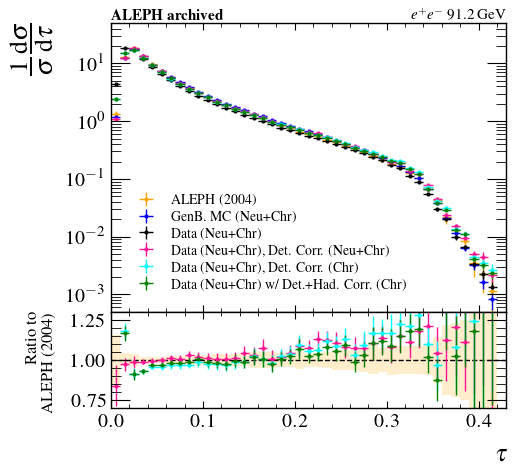

In [49]:
# closure check
fig, axs = plt.subplots(
    2, 1,
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]},  # top panel taller, bottom three equal
    figsize=[5,5]
)
plt.subplots_adjust(hspace=0)

# aleph
axs[0].errorbar(
    aleph["aleph_midbins"], 
    aleph["aleph_thrust"],
    xerr=aleph["aleph_binwidths"]/2,
    yerr=aleph["aleph_thrust_errs"], 
    marker=".", 
    linestyle="None", 
    color="orange", 
    alpha=1, 
    label="ALEPH (2004)", 
    markersize=4, 
    linewidth=1
)

# mc gen
axs[0].errorbar(
    bin_centers, 
    genb_hist / genb_hist_norm, 
    xerr=bin_widths/2, 
    yerr=genb_hist_stat_uncert / genb_hist_norm, 
    marker=".", 
    linestyle="None", 
    color="b", 
    alpha=1, 
    ecolor='b', 
    label="GenB. MC (Neu+Chr)", 
    markersize=4, 
    linewidth=1
)

# # mc gen
# axs[0].errorbar(
#     bin_centers, 
#     c_genb_hist / c_genb_hist_norm, 
#     xerr=bin_widths/2, 
#     yerr=c_genb_hist_stat_uncert / c_genb_hist_norm, 
#     marker=".", 
#     linestyle="None", 
#     color="yellow", 
#     alpha=1, 
#     label="ALEPH GenB. MC (Chr)", 
#     markersize=4, 
#     linewidth=1
# )


# data
axs[0].errorbar(
    bin_centers, 
    data_hist / data_hist_norm, 
    xerr=bin_widths/2, 
    yerr=data_hist_stat_uncert / data_hist_norm, 
    marker=".", 
    linestyle="None", 
    color="k", 
    alpha=1, 
    ecolor='k', 
    label="Data (Neu+Chr)", 
    markersize=4, 
    linewidth=1
)

# data
axs[0].errorbar(
    bin_centers, 
    data_hist_det_corr / data_hist_det_corr_norm, 
    xerr=bin_widths/2, 
    yerr=data_hist_det_corr_stat_uncert / data_hist_det_corr_norm, 
    marker=".", 
    linestyle="None", 
    color="deeppink", 
    alpha=1, 
    # ecolor='k', 
    label="Data (Neu+Chr), Det. Corr. (Neu+Chr)", 
    markersize=4, 
    linewidth=1
)

# # data
# axs[0].errorbar(
#     bin_centers, 
#     data_hist_det_had_corr / data_hist_det_had_corr_norm, 
#     xerr=bin_widths/2, 
#     yerr=data_hist_det_had_corr_stat_uncert / data_hist_det_had_corr_norm, 
#     marker=".", 
#     linestyle="None", 
#     color="purple", 
#     alpha=1, 
#     # ecolor='k', 
#     label="Data (Neu+Chr), Det.+Had. Corr. (Neu+Chr)", 
#     markersize=4, 
#     linewidth=1
# )

# # data
# axs[0].errorbar(
#     bin_centers, 
#     c_data_hist / c_data_hist_norm, 
#     xerr=bin_widths/2, 
#     yerr=c_data_hist_stat_uncert / c_data_hist_norm, 
#     marker=".", 
#     linestyle="None", 
#     color="red", 
#     alpha=1, 
#     label="ALEPH Data Raw (Chr)", 
#     markersize=4, 
#     linewidth=1
# )

# data
axs[0].errorbar(
    bin_centers, 
    c_data_hist_det_corr / c_data_hist_det_corr_norm, 
    xerr=bin_widths/2, 
    yerr=c_data_hist_det_corr_stat_uncert / c_data_hist_det_corr_norm, 
    marker=".", 
    linestyle="None", 
    color="cyan", 
    alpha=1, 
    # ecolor='k', 
    label="Data (Neu+Chr), Det. Corr. (Chr)", 
    markersize=4, 
    linewidth=1
)

# data
axs[0].errorbar(
    bin_centers, 
    c_data_hist_det_had_corr / c_data_hist_det_had_corr_norm, 
    xerr=bin_widths/2, 
    yerr=c_data_hist_det_had_corr_stat_uncert / c_data_hist_det_had_corr_norm, 
    marker=".", 
    linestyle="None", 
    color="green", 
    alpha=1, 
    # ecolor='k', 
    label="Data (Neu+Chr) w/ Det.+Had. Corr. (Chr)", 
    markersize=4, 
    linewidth=1
)

# header
axs[0].text(0, 1.0, r"$\textbf{ALEPH\ archived}$", transform=axs[0].transAxes, ha='left', va='bottom', fontsize=11)
axs[0].text(0.76, 1.0, r"$e^{+}e^{-}$ 91.2 GeV", transform=axs[0].transAxes, ha='left', va='bottom', fontsize=11)

# labels
axs[0].set_ylabel(r"$\frac{{1}}{{\sigma}} \frac{{\mathrm{d}\sigma}}{{\mathrm{d}\tau}}$", fontsize=25)
axs[0].set_yscale("log")
axs[0].set_ylim(5*10**-4, 5*10**1)

# legend
axs[0].legend(ncol=1, fontsize=10, title="", title_fontsize=15)

# ratios
axs[1].axhline(y=1, color='black', linestyle='--', alpha=1, lw=1)
axs[1].set_ylim(0.7, 1.3)
axs[1].set_xlim(0, 0.43)
axs[1].set_xlabel(r"$\tau$")
axs[1].set_ylabel("Ratio to\n ALEPH (2004)", fontsize=12)
# axs[1].set_ylabel(r"$\frac{{\mathrm{Data}}}{{\mathrm{ALEPH(2004)}}}$", fontsize=20)

# plot unifold uncertainty band
ut.plotBand(
    axs[1], 
    bin_centers, 
    np.ones(bin_centers.shape), 
    aleph["aleph_thrust_errs"]/aleph["aleph_thrust"], 
    bin_widths, 
    "orange", 
    alpha=0.2
)

# # data
# axs[1].errorbar(
#     bin_centers, 
#     data_to_aleph, 
#     xerr=bin_widths/2, 
#     yerr= data_to_aleph_uncert, 
#     marker=".", 
#     linestyle="None", 
#     color="k", 
#     alpha=1, 
#     ecolor='k', 
#     label="ALEPH Data Raw", 
#     markersize=4, 
#     linewidth=1
# )

# data
axs[1].errorbar(
    bin_centers, 
    data_det_corr_to_aleph, 
    xerr=bin_widths/2, 
    yerr=data_det_corr_to_aleph_uncert, 
    marker=".", 
    linestyle="None", 
    color="deeppink", 
    alpha=1, 
    # ecolor='k', 
    label="ALEPH Data Det. Corr. (Neu+Chr)", 
    markersize=4, 
    linewidth=1
)

# # data
# axs[1].errorbar(
#     bin_centers, 
#     data_det_had_corr_to_aleph, 
#     xerr=bin_widths/2, 
#     yerr=data_det_had_corr_to_aleph_uncert,
#     marker=".", 
#     linestyle="None", 
#     color="purple", 
#     alpha=1, 
#     # ecolor='k', 
#     label="ALEPH Data Det.+Had. Corr. (Neu+Chr)", 
#     markersize=4, 
#     linewidth=1
# )

# data
axs[1].errorbar(
    bin_centers, 
    c_data_det_corr_to_aleph, 
    xerr=bin_widths/2, 
    yerr=c_data_det_corr_to_aleph_uncert,
    marker=".", 
    linestyle="None", 
    color="cyan", 
    alpha=1, 
    # ecolor='k', 
    label="ALEPH Data Det. Corr. (Chr)", 
    markersize=4, 
    linewidth=1
)

axs[1].errorbar(
    bin_centers, 
    c_data_det_had_corr_to_aleph,  
    xerr=bin_widths/2, 
    yerr=c_data_det_had_corr_to_aleph_uncert,
    marker=".", 
    linestyle="None", 
    color="green", 
    alpha=1, 
    # ecolor='k', 
    label="ALEPH Data Det.+Had. Corr. (Chr)", 
    markersize=4, 
    linewidth=1
)

# # mc gen
# axs[1].errorbar(
#     bin_centers, 
#     genb_to_aleph, 
#     xerr=bin_widths/2, 
#     yerr=genb_to_aleph_uncert, 
#     marker=".", 
#     linestyle="None", 
#     color="b", 
#     alpha=1, 
#     ecolor='b', 
#     label="ALEPH GenB. MC", 
#     markersize=4, 
#     linewidth=1
# )

plt.show()

In [34]:
print(det_corr)
print(had_corr)

[0.25180747 0.68658238 1.07772712 1.11899383 1.10940121 1.12247379
 1.12352972 1.12610764 1.13983169 1.12192274 1.1437923  1.13670047
 1.13512496 1.12248755 1.1668175  1.13079507 1.18653051 1.11700028
 1.12969716 1.12764444 1.13473896 1.1530153  1.2231383  1.17781589
 1.18913548 1.12202797 1.18834459 1.13247101 1.14764398 1.16761543
 1.12933526 1.21786691 1.22580645 1.40306122 1.45231608 1.52261307
 1.21232877 1.59322034 1.42105263 1.47058824 2.         1.6       ]
[1.31789064 1.28536333 1.28355392 1.29457201 1.30163352 1.30905187
 1.31637012 1.31874331 1.31264215 1.31411084 1.30677078 1.31423343
 1.3045958  1.31802877 1.29894864 1.2979798  1.2882667  1.29114084
 1.27214035 1.27368753 1.26490887 1.26600312 1.25831703 1.23956311
 1.25181058 1.23995014 1.21855011 1.22686097 1.21487226 1.22860238
 1.2028151  1.21482036 1.21804511 1.2        1.21013133 1.23762376
 1.14689266 1.21276596 1.14814815 1.24       1.14285714 1.        ]
